In [3]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import pairwise_distances
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors

df = pd.read_csv('ship.csv')
df.head()


,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
0,2023-06-04,Container Ship,NaN,Heavy Fuel Oil (HFO),Critical,12.597558,2062.983982,1030.943616,14.132284,Moderate,1959.017882,483832.354540,292183.273104,25.867077,1.455179,1.415653,1,93.769249
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244
3,2023-06-25,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698
4,2023-07-02,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581


In [4]:
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

numerical_cols = [
    'Speed_Over_Ground_knots', 'Engine_Power_kW', 'Distance_Traveled_nm',
    'Draft_meters', 'Cargo_Weight_tons', 'Operational_Cost_USD',
    'Revenue_per_Voyage_USD', 'Turnaround_Time_hours', 'Efficiency_nm_per_kWh',
    'Seasonal_Impact_Score', 'Weekly_Voyage_Count', 'Average_Load_Percentage'
]
df_no_outliers = remove_outliers_iqr(df, numerical_cols)
print(f"Было: {len(df)}, стало: {len(df_no_outliers)}")
df = df_no_outliers.reset_index(drop=True)

Было: 2736, стало: 2736


In [5]:
categorical_cols = ['Ship_Type', 'Route_Type', 'Engine_Type', 'Maintenance_Status', 'Weather_Condition']
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

In [6]:
eff = df['Efficiency_nm_per_kWh']
df['Efficiency_Class'] = pd.qcut(eff, q=3, labels=['Low', 'Medium', 'High'])


In [7]:
features_to_drop = ['Date', 'Efficiency_nm_per_kWh']
X = df.drop(columns=features_to_drop + ['Efficiency_Class'])
y = df['Efficiency_Class']

In [8]:
df_cluster = df.drop(columns=features_to_drop + ['Efficiency_Class'])
X = df_cluster.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [9]:
X = X_scaled

In [10]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Числовые признаки:", len(numeric_features))
print("Категориальные признаки:", len(categorical_features))

Числовые признаки: 16
Категориальные признаки: 0


In [11]:
corr_matrix = X[numeric_features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(upper[col] > 0.85)]
print("Высококоррелированные признаки (>0.85):", high_corr)
to_drop_corr = []
for col in high_corr:
    if col not in to_drop_corr:
        correlated_cols = upper.index[upper[col] > 0.85].tolist()
        if correlated_cols:
            to_drop_corr.append(correlated_cols[0])
to_drop_corr = list(set(to_drop_corr))
print("Будем удалять:", to_drop_corr)
X_no_corr = X.drop(columns=to_drop_corr)

Высококоррелированные признаки (>0.85): []
Будем удалять: []


In [12]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
selector_f = SelectKBest(score_func=f_classif, k=10)
X_f = selector_f.fit_transform(X_no_corr, y)
selected_f = X_no_corr.columns[selector_f.get_support()].tolist()
selector_mi = SelectKBest(score_func=mutual_info_classif, k=10)
X_mi = selector_mi.fit_transform(X_no_corr, y)
selected_mi = X_no_corr.columns[selector_mi.get_support()].tolist()
print("\nТоп-10 по f_classif:")
print(selected_f)
print("\nТоп-10 по mutual_info:")
print(selected_mi)


Топ-10 по f_classif:
['Route_Type', 'Engine_Type', 'Distance_Traveled_nm', 'Draft_meters', 'Weather_Condition', 'Cargo_Weight_tons', 'Revenue_per_Voyage_USD', 'Seasonal_Impact_Score', 'Weekly_Voyage_Count', 'Average_Load_Percentage']

Топ-10 по mutual_info:
['Engine_Type', 'Draft_meters', 'Weather_Condition', 'Cargo_Weight_tons', 'Operational_Cost_USD', 'Revenue_per_Voyage_USD', 'Turnaround_Time_hours', 'Seasonal_Impact_Score', 'Weekly_Voyage_Count', 'Average_Load_Percentage']


In [13]:
seeds = [0, 42, 123, 777]
sets_mi = []
for seed in seeds:
    sel = SelectKBest(score_func=lambda X, y: mutual_info_classif(X, y, random_state=seed), k=10)
    sel.fit(X_no_corr, y)
    sets_mi.append(set(X_no_corr.columns[sel.get_support()]))
common = sets_mi[0]
for s in sets_mi[1:]:
    common = common & s
print("Устойчивые признаки (встречаются при всех random_state):")
print(list(common))
print("Количество:", len(common))

Устойчивые признаки (встречаются при всех random_state):
['Average_Load_Percentage', 'Revenue_per_Voyage_USD', 'Seasonal_Impact_Score', 'Turnaround_Time_hours', 'Cargo_Weight_tons', 'Weekly_Voyage_Count', 'Weather_Condition', 'Operational_Cost_USD']
Количество: 8


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(n_estimators=100, random_state=42)
scores_full = cross_val_score(model, X_no_corr, y, cv=5, scoring='f1_weighted')
X_mi_df = X_no_corr[selected_mi]
scores_mi = cross_val_score(model, X_mi_df, y, cv=5, scoring='f1_weighted')
print("Сравнение качества (F1-weighted, 5-fold CV):")
print(f"Полные данные (без корреляций): {scores_full.mean():.4f} ± {scores_full.std():.4f}")
print(f"Отобранные (mutual_info): {scores_mi.mean():.4f} ± {scores_mi.std():.4f}")

Сравнение качества (F1-weighted, 5-fold CV):
Полные данные (без корреляций): 0.3302 ± 0.0082
Отобранные (mutual_info): 0.3452 ± 0.0161


In [15]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
base_score = cross_val_score(rf_base, X, y, cv=5, scoring='f1_weighted').mean()
print(f"Базовый F1 (все признаки): {base_score:.4f}")

Базовый F1 (все признаки): 0.3302


In [17]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
importances = rf.feature_importances_
feature_names = X.columns
top5_fi = [feature_names[i] for i in np.argsort(importances)[-5:][::-1]]
print("Топ-5 (Feature Importances):", top5_fi)

Топ-5 (Feature Importances): ['Revenue_per_Voyage_USD', 'Distance_Traveled_nm', 'Draft_meters', 'Turnaround_Time_hours', 'Cargo_Weight_tons']


In [18]:
from sklearn.feature_selection import RFE
rfe = RFE(estimator=RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=1, step=1)
rfe.fit(X, y)
ranking = rfe.ranking_
top5_rfe = [feature_names[i] for i in np.argsort(ranking)[:5]]
print("Топ-5 (RFE):", top5_rfe)

Топ-5 (RFE): ['Operational_Cost_USD', 'Turnaround_Time_hours', 'Revenue_per_Voyage_USD', 'Draft_meters', 'Average_Load_Percentage']


In [19]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
lr.fit(X, y_encoded)
coef_abs = np.max(np.abs(lr.coef_), axis=0)
top5_l1 = [feature_names[i] for i in np.argsort(coef_abs)[-5:][::-1]]
print("Топ-5 (L1):", top5_l1)

Топ-5 (L1): ['Engine_Type', 'Weather_Condition', 'Revenue_per_Voyage_USD', 'Distance_Traveled_nm', 'Weekly_Voyage_Count']


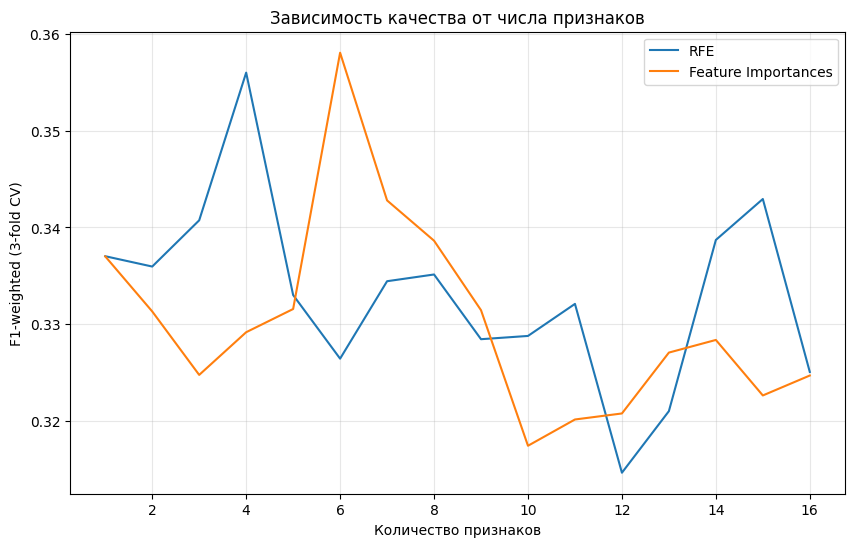

In [20]:
def plot_feature_selection_curve(selector, X, y, method_name, scoring='f1_weighted'):
    scores = []
    n_features = []
    for n in range(1, X.shape[1] + 1):
        sel = selector(n_features_to_select=n)
        X_sel = sel.fit_transform(X, y)
        score = cross_val_score(rf_base, X_sel, y, cv=3, scoring=scoring).mean()
        scores.append(score)
        n_features.append(n)
    plt.plot(n_features, scores, label=method_name)
    return n_features, scores
plt.figure(figsize=(10, 6))
rfe_scores = []
for n in range(1, X.shape[1] + 1):
    rfe_temp = RFE(estimator=RandomForestClassifier(n_estimators=50, random_state=42), n_features_to_select=n, step=1)
    X_rfe = rfe_temp.fit_transform(X, y)
    score = cross_val_score(RandomForestClassifier(n_estimators=50, random_state=42), X_rfe, y, cv=3, scoring='f1_weighted').mean()
    rfe_scores.append(score)
plt.plot(range(1, X.shape[1]+1), rfe_scores, label='RFE')
importances = rf.feature_importances_
fi_scores = []
for n in range(1, X.shape[1] + 1):
    top_idx = np.argsort(importances)[-n:]
    X_fi = X.iloc[:, top_idx]
    score = cross_val_score(rf_base, X_fi, y, cv=3, scoring='f1_weighted').mean()
    fi_scores.append(score)
plt.plot(range(1, X.shape[1]+1), fi_scores, label='Feature Importances')
plt.xlabel('Количество признаков')
plt.ylabel('F1-weighted (3-fold CV)')
plt.title('Зависимость качества от числа признаков')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

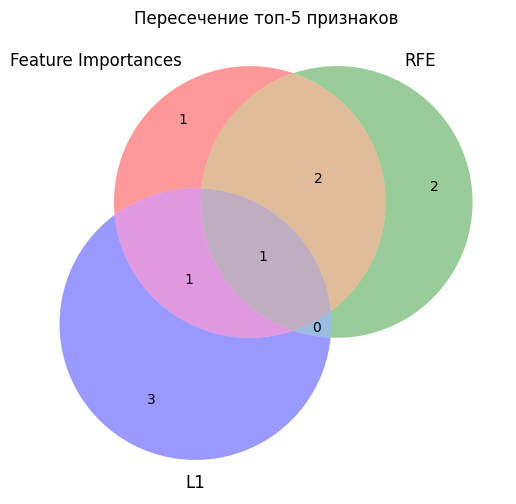

In [21]:
from matplotlib_venn import venn3

set_fi = set(top5_fi)
set_rfe = set(top5_rfe)
set_l1 = set(top5_l1)

plt.figure(figsize=(8, 6))
venn3([set_fi, set_rfe, set_l1], set_labels=('Feature Importances', 'RFE', 'L1'))
plt.title('Пересечение топ-5 признаков')
plt.show()

In [ ]:
np.random.seed(42)
for i in range(1, 6):
    X[f'random_feature_{i}'] = np.random.randn(len(X))
print("Форма X после добавления шума:", X.shape)

Форма X после добавления шума: (2736, 21)


In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model_cb = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=False
)
model_cb.fit(X_train, y_train)
y_pred = model_cb.predict(X_test)
f1_full = f1_score(y_test, y_pred, average='weighted')
print(f"F1-weighted (полная модель): {f1_full:.4f}")

F1-weighted (полная модель): 0.2952


In [ ]:
from sklearn.inspection import permutation_importance
perm_imp = permutation_importance(
    model_cb, X_test, y_test,
    scoring='f1_weighted',
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
perm_indices = np.argsort(perm_imp.importances_mean)[::-1]
perm_features = X.columns[perm_indices]
perm_scores = perm_imp.importances_mean[perm_indices]
print("Permutation Importance (топ-10):")
for i in range(10):
    print(f"{i+1}. {perm_features[i]}: {perm_scores[i]:.4f}")


Permutation Importance (топ-10):
1. Weather_Condition: 0.0174
2. Route_Type: 0.0129
3. Revenue_per_Voyage_USD: 0.0103
4. random_feature_2: 0.0027
5. random_feature_4: -0.0003
6. Average_Load_Percentage: -0.0008
7. Engine_Type: -0.0018
8. Engine_Power_kW: -0.0059
9. Maintenance_Status: -0.0063
10. Operational_Cost_USD: -0.0076


In [ ]:
import shap
explainer = shap.TreeExplainer(model_cb)
shap_values = explainer.shap_values(X_test)
mean_abs_shap = np.mean(np.abs(shap_values), axis=(0, 2))
shap_indices = np.argsort(mean_abs_shap)[::-1]
shap_features = X.columns[shap_indices]
print("SHAP (топ-10):")
for i in range(10):
    print(f"{i+1}. {shap_features[i]}: {mean_abs_shap[shap_indices[i]]:.4f}")


SHAP (топ-10):
1. Revenue_per_Voyage_USD: 0.0679
2. Draft_meters: 0.0619
3. random_feature_1: 0.0619
4. random_feature_5: 0.0598
5. Average_Load_Percentage: 0.0549
6. Operational_Cost_USD: 0.0530
7. random_feature_4: 0.0509
8. random_feature_3: 0.0509
9. Seasonal_Impact_Score: 0.0502
10. Engine_Type: 0.0495


C:\Users\Пользователь\AppData\Local\Temp\ipykernel_18308\243396988.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test, max_display=15)


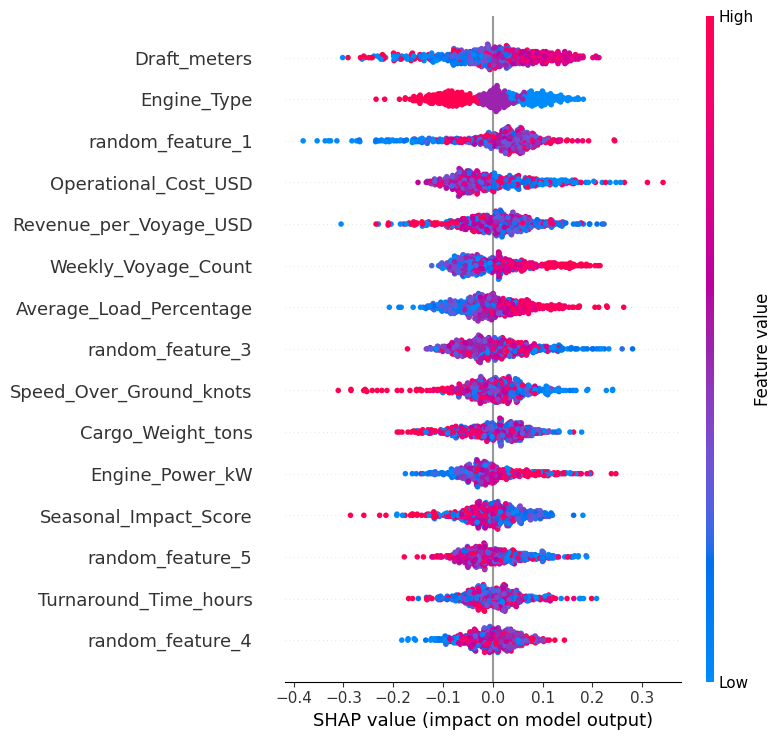

In [26]:
shap.summary_plot(shap_values[:, :, 1], X_test, max_display=15)

In [ ]:
least_important = perm_features[-5:]
X_reduced = X.drop(columns=least_important)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)
import time
start = time.time()
model_cb_r = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=False
)
model_cb_r.fit(X_train_r, y_train_r)
time_reduced = time.time() - start
y_pred_r = model_cb_r.predict(X_test_r)
f1_reduced = f1_score(y_test_r, y_pred_r, average='weighted')
print(f"Сравнение:")
print(f"Полная модель:   F1 = {f1_full:.4f}")
print(f"Сокращённая:     F1 = {f1_reduced:.4f}")
print(f"Время обучения сокращённой модели: {time_reduced:.2f} сек")


Сравнение:
Полная модель:   F1 = 0.2952
Сокращённая:     F1 = 0.3181
Время обучения сокращённой модели: 1.59 сек
